In [85]:
import timeit as t
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
#### %matplotlib notebook
%matplotlib inline

# Setup styles for plotting
style_list = ['default', 'classic'] + sorted(
        style for style in plt.style.available if style != 'classic')
plt.style.use(style_list[10])
print(style_list)

['default', 'classic', 'Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [86]:
# 2.1 Function to find Nth Fibonacci term
def FibonacciRec(N:int):
    # Base Case
    if (N < 2):
        return N

    # Recursively computing the term
    # using recurrence relation
    return FibonacciRec(N - 1) + FibonacciRec(N - 2)

# Test fibonacci: compute results for N 1 .. 20
for i in range(1,20):
    f10 = FibonacciRec(i)
    print(f10)


1
1
2
3
5
8
13
21
34
55
89
144
233
377
610
987
1597
2584
4181


### 2.1 Merjenje časa izvajanja
Za pravilno meritev časa izvajanja bomo uporabljali funkcijo `timeit()`, namenjeno testiranju hitrosti manjših koščkov kode. Uporablja se na naslednji način, primer:
`t.timeit('quicksort(data)','from __main__ import data,quicksort', number = num)`

Prvi niz je ukaz, ki ga merimo, nato drugi niz definira importe oziroma knjižnice, nato pa še, kolikokrat želimo izvesti ta ukaz (večkrat je bolj zanesljiva meritev časa). 

In [87]:
# Measure execution time : 
fibNumber = 40

t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)

print('Fibonnaci for ', fibNumber, ' execution time sec: ', t_fib)

Fibonnaci for  40  execution time sec:  20.01935630000662


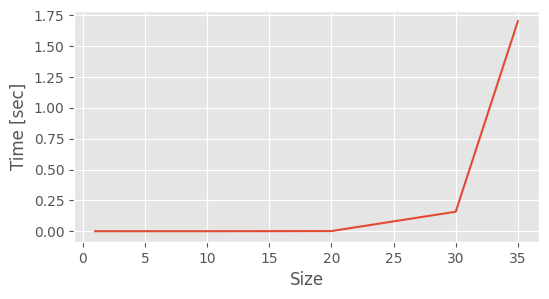

In [88]:
# 2.3 Plot graph of Fibonnaci execution time

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,20,30,35]
# zanka
for n in n_list:
    fibNumber = n
    t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)
    t_list = np.append(t_list, t_fib)

ax = plt.figure(figsize=[6,3])
plt.plot(n_list, t_list)
plt.xlabel('Size')
plt.ylabel('Time [sec]')
plt.show()


In [89]:
# 2.4 Class for algorithm testing
from utils import Algorithm

# Testing
a = Algorithm()



In [90]:
# 2.5  Fibonnaci algoritem z uporabo Alogrithm
# Prva verzija, kjer je N dolocen s stevilom ponovitev

class FibonacciRecursion(Algorithm):
    def __init__(self):
        self.name = "FibonacciRecursion"

    # Function to find Nth Fibonacci term
    def FibonacciR(self, N:int):
        # Count each call of the function
        self.count_op += 1

        # Base Case
        if (N < 2):
            return N

        # Recursively computing the term
        # using recurrence relation
        return self.FibonacciR(N - 1) + self.FibonacciR(N - 2)

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.FibonacciR(N)

        return self.result_data


s = FibonacciRecursion()
s.data_params = {'N': 30}
print('Test result: ', s.run(3))


 >>  0 , msec: 368.286 , operations:  2692537
 >>  1 , msec: 351.669 , operations:  2692537
 >>  2 , msec: 361.071 , operations:  2692537
 >>>  FibonacciRecursion  > Total run() sec:  1.0826851000310853  Avg iter msec: 360.8950333436951
Test result:  {'name': 'FibonacciRecursion', 'avg_msec': 360.8950333436951, 'avg_O': 2692537.0, 'niter': 3, 'output': 832040}


 >>  0 , msec: 0.005 , operations:  1
 >>>  FibonacciRecursion  > Total run() sec:  0.0003497999859973788  Avg iter msec: 0.3497999859973788
 >>  0 , msec: 0.004 , operations:  5
 >>>  FibonacciRecursion  > Total run() sec:  3.2400013878941536e-05  Avg iter msec: 0.032400013878941536
 >>  0 , msec: 0.005 , operations:  15
 >>>  FibonacciRecursion  > Total run() sec:  2.7999980375170708e-05  Avg iter msec: 0.027999980375170708
 >>  0 , msec: 0.029 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  4.9900030717253685e-05  Avg iter msec: 0.049900030717253685
 >>  0 , msec: 0.432 , operations:  1973
 >>>  FibonacciRecursion  > Total run() sec:  0.0005106000462546945  Avg iter msec: 0.5106000462546945
 >>  0 , msec: 4.830 , operations:  21891
 >>>  FibonacciRecursion  > Total run() sec:  0.004917800077237189  Avg iter msec: 4.917800077237189
 >>  0 , msec: 67.271 , operations:  242785
 >>>  FibonacciRecursion  > Total run() sec:  0.06737379997503012  Avg iter msec: 67.37379997

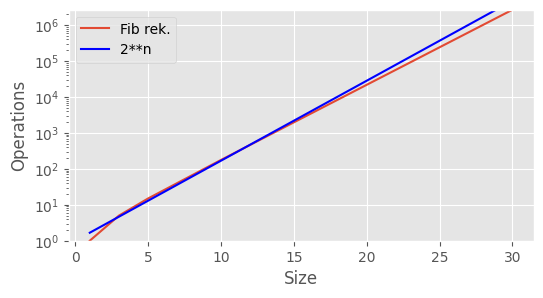

In [91]:
# 2.6 Testing Fibonacci recursion

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30]

s = FibonacciRecursion()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])



ax = plt.figure(figsize=[6,3])
plt.plot(n_list, oper_list, label='Fib rek.')

O2n = [np.float_power(1.67, n) for n in n_list]
plt.plot(n_list, O2n, 'b', label='2**n')

plt.ylim(1, max(oper_list))
plt.yscale('log')
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()

plt.show()

In [92]:
# 2.7 Fibonnaci algorithm optimized

class FibonacciOptimized(Algorithm):
    def __init__(self):
        self.name = "FibonacciOptimized"

    # Function to find Nth Fibonacci term
    def Fibonacci(self, N):
        f=[0]*(N + 2)
        # 0th and 1st number of the
        # series are 0 and 1
        f[0] = 0
        f[1] = 1
        # Iterate over the range [2, N]
        for i in range(2,N+1) :
            self.count_op += 1
            # Add the previous 2 numbers
            # in the series and store it
            f[i] = f[i - 1] + f[i - 2]
        # Return Nth Fibonacci Number
        return f[N]

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.Fibonacci(N)

        return self.result_data


s = FibonacciOptimized()
s.data_params = {'N': 10}
print(s.run(1))



 >>  0 , msec: 0.015 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  0.0003461999585852027  Avg iter msec: 0.3461999585852027
{'name': 'FibonacciOptimized', 'avg_msec': 0.3461999585852027, 'avg_O': 9.0, 'niter': 1, 'output': 55}


 >>  0 , msec: 0.020 , operations:  0
 >>>  FibonacciOptimized  > Total run() sec:  0.0005422000540420413  Avg iter msec: 0.5422000540420413
 >>  0 , msec: 0.006 , operations:  2
 >>>  FibonacciOptimized  > Total run() sec:  6.059999577701092e-05  Avg iter msec: 0.06059999577701092
 >>  0 , msec: 0.005 , operations:  4
 >>>  FibonacciOptimized  > Total run() sec:  4.1499966755509377e-05  Avg iter msec: 0.041499966755509377
 >>  0 , msec: 0.005 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  4.0199956856667995e-05  Avg iter msec: 0.040199956856667995
 >>  0 , msec: 0.007 , operations:  14
 >>>  FibonacciOptimized  > Total run() sec:  4.429998807609081e-05  Avg iter msec: 0.04429998807609081
 >>  0 , msec: 0.009 , operations:  19
 >>>  FibonacciOptimized  > Total run() sec:  4.509999416768551e-05  Avg iter msec: 0.04509999416768551
 >>  0 , msec: 0.009 , operations:  24
 >>>  FibonacciOptimized  > Total run() sec:  4.4599990360438824e-05  Avg iter msec: 0.04459999036043882

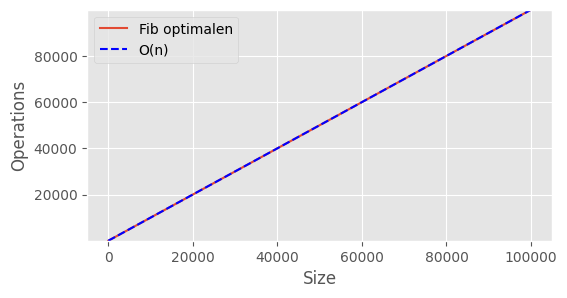

In [93]:
# 2.7 Testing Fibonacci optimized

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15, 20, 25, 30, 100, 1000, 10000, 100000]

s = FibonacciOptimized()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

ax = plt.figure(figsize=[6,3])
plt.plot(n_list, oper_list, label='Fib optimalen')

#O2n = [np.float_power(1.67, n) for n in n_list]
#plt.plot(n_list, O2n, 'b', label='2**n')

Olin = [n for n in n_list]
plt.plot(n_list, Olin, 'b--', label='O(n)')

plt.ylim(1, max(oper_list))
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.show()


### 3. Sortirni algoritmi

Testiramo in primerjamo delovanje različnih algoritmov sortiranja števil od najmanjšega do največjega. Pri tem imamo več scenarijev, glede na vhodne podatke:
* **optimalni**, v tem primeru so števila že urejena v želenem vrstnem redu
* **najslabši**, podatki so urejeni v obratnem vrstnem redu kot želimo
* **normalni**, podatki so urejeni naključno.


In [94]:
def insertionSort2(array):
    d = array.copy()
    for j in range(1, len(d)):
        key = d[j]
        i = j - 1
        while i >= 0 and d[i] > key:
            d[i + 1] = d[i]
            i = i - 1
        d[i + 1] = key
    return d

In [95]:
# Vrne set podatkov
def createSet(type = None, size = 100):
    if type == 1:  #return numbers sorted in ascening order -> best case
        return np.linspace(1,size,size).tolist() 
    elif type == 2: #return numbers in descending order -> wost case
        return np.linspace(size,1,size).tolist()
    else: #return a random assortment of numbers
        return (np.trunc(np.absolute(size*10/2.0 + size*10/5.0*np.random.randn(size)))/10).tolist()

In [96]:
# 3.1 Preskus parametrov type, size: izpiši dobljene podatke
print(createSet(1, 20))
print('Neurejeni',createSet(0, 20))
print('Od najv do najm:', createSet(2, 20))

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
Neurejeni [13.4, 8.1, 17.5, 12.9, 11.0, 9.7, 13.3, 13.3, 3.2, 15.0, 6.2, 10.5, 10.0, 12.9, 8.0, 13.0, 15.6, 3.1, 5.1, 7.0]
Od najv do najm: [20.0, 19.0, 18.0, 17.0, 16.0, 15.0, 14.0, 13.0, 12.0, 11.0, 10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]


In [97]:
# 3.3 Preskus insertionSort2
podatki = createSet(0, 100)
urejeni = insertionSort2(podatki)
print(urejeni)

[1.5, 4.6, 6.1, 9.6, 11.7, 13.4, 17.6, 21.7, 21.8, 24.4, 25.0, 26.1, 26.3, 27.1, 27.4, 28.5, 29.1, 31.0, 31.6, 32.0, 32.4, 32.4, 34.2, 37.0, 37.2, 37.2, 38.2, 38.4, 38.5, 39.8, 41.1, 42.1, 42.4, 42.8, 42.8, 42.9, 43.2, 43.4, 44.0, 44.0, 44.0, 45.0, 45.2, 45.5, 46.7, 46.7, 47.4, 48.0, 48.2, 48.2, 49.2, 49.2, 49.4, 49.6, 49.9, 50.4, 50.6, 52.7, 53.6, 54.2, 55.0, 55.6, 56.4, 57.0, 57.4, 57.6, 57.9, 58.1, 58.2, 58.4, 58.7, 58.8, 59.3, 59.5, 59.8, 60.2, 61.8, 62.1, 62.4, 62.6, 63.9, 64.5, 66.7, 67.0, 68.3, 68.3, 70.2, 71.7, 73.9, 75.3, 76.1, 76.7, 80.2, 80.4, 84.2, 85.1, 86.0, 86.7, 88.4, 104.6]


In [98]:
class InsertionSort(Algorithm):
    def __init__(self):
        self.name = "Insertion Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()

    def insertionSort(self, array):
        d = array.copy()
        for j in range(1, len(d)):
            key = d[j]
            i = j - 1
            while i >= 0 and d[i] > key:
                self.count_op+=1
                d[i + 1] = d[i]
                i = i - 1
            d[i + 1] = key
        return d


    def run_once(self):
        self.result_data = self.insertionSort(self.input_data)
        return self.result_data

In [99]:
# 3.4 Testiraj InsertionSort razred
s = InsertionSort()
s.data_params = {'size': 1000, 'type': 0}

print(s.run(5))



 >>  0 , msec: 63.772 , operations:  258265
 >>  1 , msec: 84.360 , operations:  254936
 >>  2 , msec: 42.859 , operations:  241922
 >>  3 , msec: 40.315 , operations:  262942
 >>  4 , msec: 37.262 , operations:  255438
 >>>  Insertion Sort  > Total run() sec:  0.26931660005357116  Avg iter msec: 53.86332001071423
{'name': 'Insertion Sort', 'avg_msec': 53.86332001071423, 'avg_O': 254700.6, 'niter': 5, 'output': [3.9, 5.3, 6.4, 6.5, 10.0, 10.6, 12.6, 13.3, 13.8, 18.4, 24.9, 29.8, 31.2, 36.6, 37.0, 41.0, 46.8, 51.5, 53.5, 55.7, 61.4, 66.0, 66.6, 71.6, 76.3, 77.7, 79.0, 81.1, 84.1, 85.1, 85.2, 86.2, 86.9, 89.5, 91.7, 93.0, 93.3, 97.6, 97.9, 100.0, 104.7, 111.0, 113.8, 115.2, 116.2, 117.8, 127.7, 132.8, 141.3, 142.2, 149.9, 151.5, 152.2, 155.0, 157.0, 157.5, 158.8, 159.0, 159.6, 160.1, 162.1, 168.3, 169.3, 170.6, 173.2, 175.7, 180.9, 184.6, 184.7, 185.3, 186.9, 188.2, 189.6, 190.6, 192.2, 192.4, 193.6, 194.3, 197.2, 197.3, 199.9, 200.7, 201.8, 201.8, 202.1, 203.5, 205.9, 206.1, 206.6, 207.

 >>  0 , msec: 0.081 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  0.00020250002853572369  Avg iter msec: 0.2025000285357237
 >>  0 , msec: 0.084 , operations:  45
 >>>  Insertion Sort  > Total run() sec:  0.00010850001126527786  Avg iter msec: 0.10850001126527786
 >>  0 , msec: 0.052 , operations:  190
 >>>  Insertion Sort  > Total run() sec:  7.459998596459627e-05  Avg iter msec: 0.07459998596459627
 >>  0 , msec: 0.205 , operations:  1225
 >>>  Insertion Sort  > Total run() sec:  0.00022769998759031296  Avg iter msec: 0.22769998759031296
 >>  0 , msec: 0.715 , operations:  4950
 >>>  Insertion Sort  > Total run() sec:  0.0007420999463647604  Avg iter msec: 0.7420999463647604
 >>  0 , msec: 3.334 , operations:  19900
 >>>  Insertion Sort  > Total run() sec:  0.0033953000092878938  Avg iter msec: 3.3953000092878938
 >>  0 , msec: 19.807 , operations:  124750
 >>>  Insertion Sort  > Total run() sec:  0.019959599943831563  Avg iter msec: 19.959599943831563
 >>  0 , msec: 87

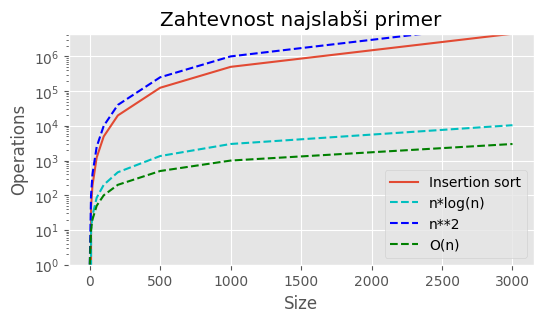

In [100]:
# 3.5 Kompleksnost Insertion sort

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000,3000]

s = InsertionSort()
s.data_params['type'] = 2
# Dodaj kodo za testiranje in izrisovanje grafa
for n in n_list:
    s.data_params['size'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

ax = plt.figure(figsize=[6,3])
plt.plot(n_list, oper_list, label='Insertion sort')

Onlogn = [n*np.log10(n) for n in n_list]
plt.plot(n_list, Onlogn, 'c--', label='n*log(n)')

On2 = [np.float_power(n, 2.0) for n in n_list]
plt.plot(n_list, On2, 'b--', label='n**2')

Olin = [n for n in n_list]
plt.plot(n_list, Olin, 'g--', label='O(n)')

plt.ylim(1, max(oper_list))
plt.yscale('log')
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.title('Zahtevnost najslabši primer')
plt.show()






In [101]:
# Opcija: uporaba tega razreda za izris
from utils import AlgorithmBenchmark


In [102]:
def quicksort(arr):
    """ Quicksort a list

    :type arr: list
    :param arr: List to sort
    :returns: list -- Sorted list
    """
    if len(arr) <= 1:
        return arr
    else:
        return quicksort([x for x in arr[1:] if x<arr[0]]) + [arr[0]] + quicksort([x for x in arr[1:] if x>=arr[0]])

In [103]:
class QuickSort(Algorithm):
    def __init__(self):
        self.name = "Quick Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()


    # Function to find the partition position
    def partition(self, array, low, high):
    
        # Choose the rightmost element as pivot
        pivot = array[high]
    
        # Pointer for greater element
        i = low - 1
    
        # Traverse through all elements
        # compare each element with pivot
        for j in range(low, high):
            if array[j] <= pivot:
    
                # If element smaller than pivot is found
                # swap it with the greater element pointed by i
                i = i + 1
    
                # Swapping element at i with element at j
                (array[i], array[j]) = (array[j], array[i])
                self.count_op+=1
    
        # Swap the pivot element with
        # the greater element specified by i
        (array[i + 1], array[high]) = (array[high], array[i + 1])
        self.count_op+=1
    
        # Return the position from where partition is done
        return i + 1
 
 
    # Function to perform quicksort
    def quicksort(self, array, low, high):
        if low < high:
    
            # Find pivot element such that
            # element smaller than pivot are on the left
            # element greater than pivot are on the right
            pi = self.partition(array, low, high)
    
            # Recursive call on the left of pivot
            self.quicksort(array, low, pi - 1)
    
            # Recursive call on the right of pivot
            self.quicksort(array, pi + 1, high)


    def run_once(self):
        N = len(self.input_data)
        self.result_data = self.quicksort(self.input_data, 0, N-1)
        return self.result_data

 >>  0 , msec: 0.063 , operations:  0
 >>>  Quick Sort  > Total run() sec:  0.0003991000121459365  Avg iter msec: 0.3991000121459365
 >>  0 , msec: 0.058 , operations:  23
 >>>  Quick Sort  > Total run() sec:  8.500006515532732e-05  Avg iter msec: 0.08500006515532732
 >>  0 , msec: 0.029 , operations:  41
 >>>  Quick Sort  > Total run() sec:  5.149992648512125e-05  Avg iter msec: 0.05149992648512125
 >>  0 , msec: 0.056 , operations:  198
 >>>  Quick Sort  > Total run() sec:  7.589999586343765e-05  Avg iter msec: 0.07589999586343765
 >>  0 , msec: 0.104 , operations:  384
 >>>  Quick Sort  > Total run() sec:  0.00012560002505779266  Avg iter msec: 0.12560002505779266
 >>  0 , msec: 0.230 , operations:  1009
 >>>  Quick Sort  > Total run() sec:  0.00025109993293881416  Avg iter msec: 0.25109993293881416
 >>  0 , msec: 0.706 , operations:  3010
 >>>  Quick Sort  > Total run() sec:  0.0007539000362157822  Avg iter msec: 0.7539000362157822
 >>  0 , msec: 1.873 , operations:  6947
 >>>  Qui

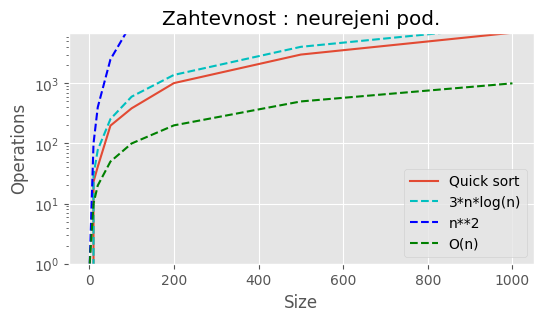

In [104]:
# 3.6 Kompleksnost Quick sort : dodaj kodo, izvedi testiranja



size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000]

s = QuickSort()
s.data_params['type'] = 0
# Dodaj kodo za testiranje in izrisovanje grafa
for n in n_list:
    s.data_params['size'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

ax = plt.figure(figsize=[6,3])
plt.plot(n_list, oper_list, label='Quick sort')

Onlogn = [3*n*np.log10(n) for n in n_list]
plt.plot(n_list, Onlogn, 'c--', label='3*n*log(n)')

On2 = [np.float_power(n, 2.0) for n in n_list]
plt.plot(n_list, On2, 'b--', label='n**2')

Olin = [n for n in n_list]
plt.plot(n_list, Olin, 'g--', label='O(n)')

plt.ylim(1, max(oper_list))
plt.yscale('log')
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.title('Zahtevnost : neurejeni pod.')
plt.show()




In [105]:
# 3.7 Opcijsko: Kompleksnost Buble sort : dodaj kodo, izvedi testiranja